In [7]:
# 사용할 JSON, jpg를 동시에 업로드 해야함
from google.colab import files

uploaded = files.upload()

Saving 11.jpg to 11.jpg
Saving 11.json to 11 (1).json
Saving 12101.jpg to 12101.jpg
Saving 12101.json to 12101 (1).json
Saving 62174.jpg to 62174.jpg
Saving 62174.json to 62174 (1).json


In [8]:
# 1. JSON 로드

import json

json_files = ["11.json", "12101.json", "62174.json"]

all_data = []

for json_file in json_files:

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_data.append(data)

    print(f"Loaded: {json_file}")

Loaded: 11.json
Loaded: 12101.json
Loaded: 62174.json


In [11]:
# 2. polygon 좌표 추출
polygon_data = data["데이터셋 정보"]["데이터셋 상세설명"]["폴리곤좌표"]["원피스"][0]

In [12]:
# 3. polygon point 변환
points = []

for i in range(1, 22):

    x_key = f"X좌표{i}"
    y_key = f"Y좌표{i}"

    if x_key in polygon_data and y_key in polygon_data:

        x = polygon_data[x_key]
        y = polygon_data[y_key]

        points.append((x, y))

print(points)

[(476.703, 7.0), (550.703, 34.0), (584.703, 221.0), (602.703, 270.0), (562.703, 296.0), (557.703, 373.0), (548.703, 504.0), (565.703, 592.0), (527.703, 611.0), (456.703, 598.0), (425.703, 588.0), (394.703, 618.0), (363.703, 596.0), (342.703, 372.0), (316.703, 293.0), (317.703, 273.0), (290.703, 174.0), (313.703, 71.0), (381.703, 5.0), (433.703, 62.0), (474.703, 7.0)]



Processing: 11.json


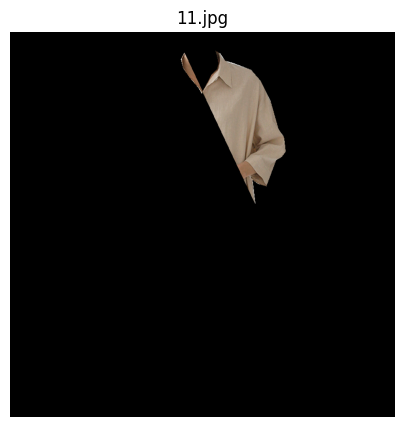


Processing: 12101.json


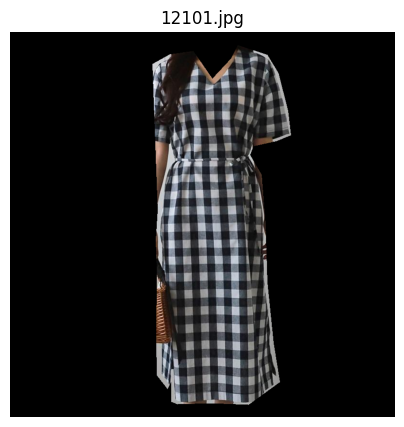


Processing: 62174.json


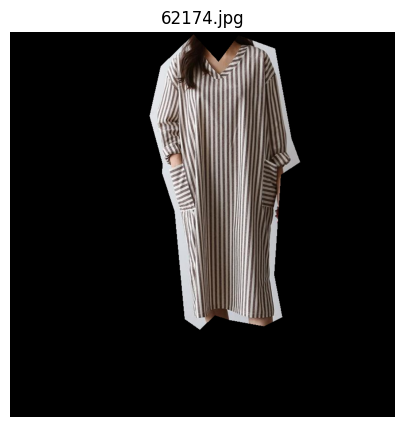

In [13]:
import json
import os
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

json_files = ["11.json", "12101.json", "62174.json"]

for json_file in json_files:

    print(f"\nProcessing: {json_file}")

    # JSON 로드
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 파일명 추출
    image_file = json_file.replace(".json", ".jpg")

    # 이미지 로드
    image = Image.open(image_file).convert("RGB")

    # polygon 데이터 추출
    polygon_data = data["데이터셋 정보"]["데이터셋 상세설명"]["폴리곤좌표"]["원피스"][0]

    # polygon points 생성
    points = []

    for i in range(1, 30):

        x_key = f"X좌표{i}"
        y_key = f"Y좌표{i}"

        if x_key in polygon_data and y_key in polygon_data:

            x = polygon_data[x_key]
            y = polygon_data[y_key]

            points.append((x, y))

    # mask 생성
    mask = Image.new("L", image.size, 0)

    ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)

    mask = np.array(mask)

    # 배경 제거
    image_np = np.array(image)

    result = np.zeros_like(image_np)

    result[mask == 1] = image_np[mask == 1]

    # 시각화
    plt.figure(figsize=(5,5))
    plt.imshow(result)
    plt.title(image_file)
    plt.axis("off")
    plt.show()

In [14]:
# 5. 배경 제거
image_np = np.array(image)

result = np.zeros_like(image_np)

result[mask == 1] = image_np[mask == 1]

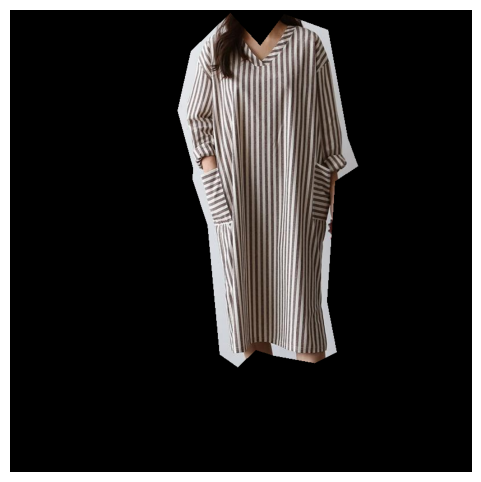

In [15]:
# 6. 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.axis("off")
plt.show()

In [16]:
# 7. bounding box crop
ys, xs = np.where(mask == 1)

x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

cropped = result[y_min:y_max, x_min:x_max]

In [17]:
# 8. cropped image 저장
cropped_img = Image.fromarray(cropped)

cropped_img.save("masked_item.jpg")

In [21]:
# 9. masked image를 Qwen2.5-VL-3B에 입력

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from PIL import Image
import torch

In [22]:
# 모델 로드
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [23]:
# masked image 로드
image = Image.open("masked_item.jpg").convert("RGB")

# 프롬프트
prompt = """
Analyze the fashion item in the image.

Extract only the following attributes and return JSON only.

{
  "pattern_direction": "",
  "detail_color": "",
  "graphic_type": ""
}

Rules:

1. pattern_direction
Choose only one:
- vertical
- horizontal
- diagonal
- mixed
- none

2. detail_color
Main color of visible detail elements such as:
- buttons
- zippers
- stripes
- stitching
- decorations

Choose one simple color or "none".

3. graphic_type
Choose only one:
- logo
- lettering
- illustration
- character
- none

Return JSON only.
"""

# 메시지 구성
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }
]

# 입력 생성
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to(model.device)

# 생성
with torch.inference_mode():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=50
    )

# prompt 부분 제거
generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

# 디코딩
generated_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)[0]

# 출력
print(generated_text)

```json
{
  "pattern_direction": "vertical",
  "detail_color": "brown",
  "graphic_type": "none"
}
```
